In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv("students.csv")

print(df.head())
print(f"\nRows: {df.shape[0]}, Columns: {df.shape[1]}")
print(df.dtypes)
print(df.describe())
print(df['passed'].value_counts())

subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\nAvg scores - passing students:")
print(df[df['passed'] == 1][subject_cols].mean().round(2))
print("\nAvg scores - failing students:")
print(df[df['passed'] == 0][subject_cols].mean().round(2))

df['temp_avg'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['temp_avg'].idxmax(), 'name']
top_avg = df['temp_avg'].max()
print(f"\nHighest overall average: {top_student} ({top_avg:.2f})")
df.drop(columns=['temp_avg'], inplace=True)

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Rows: 15, Columns: 9
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object
            math    science    english    history         pe  attendance_pct  \
coun

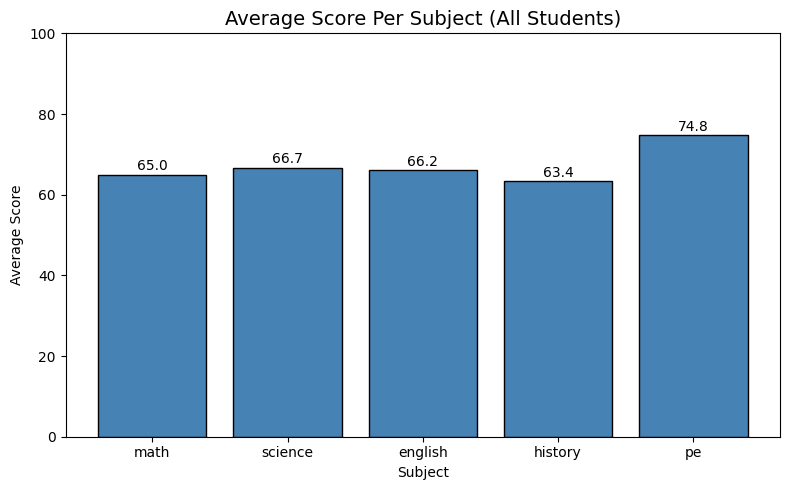

plot1_bar.png saved


In [3]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# task 2 - bar chart: avg score per subject
fig, ax = plt.subplots(figsize=(8, 5))
subject_avgs = df[subject_cols].mean()

ax.bar(subject_avgs.index, subject_avgs.values, color='steelblue', edgecolor='black')
ax.set_title("Average Score Per Subject (All Students)", fontsize=14)
ax.set_xlabel("Subject")
ax.set_ylabel("Average Score")
ax.set_ylim(0, 100)

for i, v in enumerate(subject_avgs.values):
    ax.text(i, v + 1, f"{v:.1f}", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("plot1_bar.png")
plt.show()
print("plot1_bar.png saved")

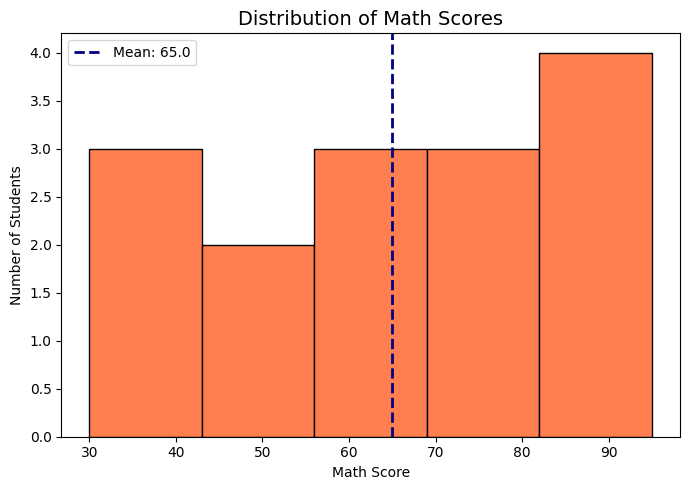

plot2_histogram.png saved


In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(df['math'], bins=5, color='coral', edgecolor='black')

mean_math = df['math'].mean()
ax.axvline(mean_math, color='navy', linestyle='--', linewidth=2, label=f'Mean: {mean_math:.1f}')

ax.set_title("Distribution of Math Scores", fontsize=14)
ax.set_xlabel("Math Score")
ax.set_ylabel("Number of Students")
ax.legend()

plt.tight_layout()
plt.savefig("plot2_histogram.png")
plt.show()
print("plot2_histogram.png saved")

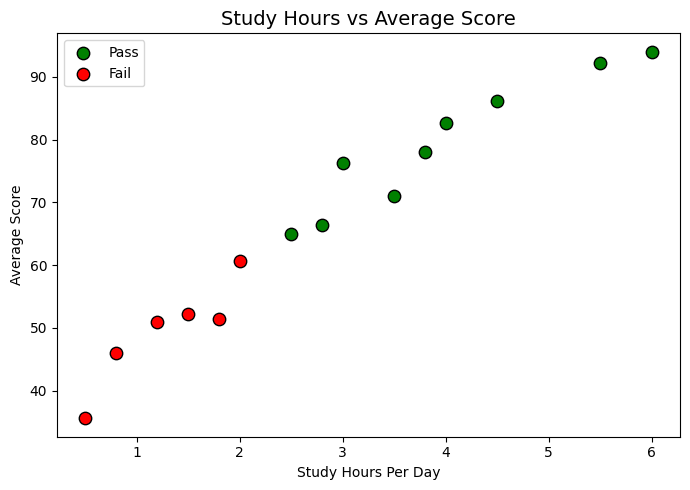

plot3_scatter.png saved


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

ax.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], color='green', label='Pass', s=80, edgecolors='black')
ax.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], color='red', label='Fail', s=80, edgecolors='black')

ax.set_title("Study Hours vs Average Score", fontsize=14)
ax.set_xlabel("Study Hours Per Day")
ax.set_ylabel("Average Score")
ax.legend()

plt.tight_layout()
plt.savefig("plot3_scatter.png")
plt.show()
print("plot3_scatter.png saved")

C:\Users\Isheeta\AppData\Local\Temp\ipykernel_8684\4254523054.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'],


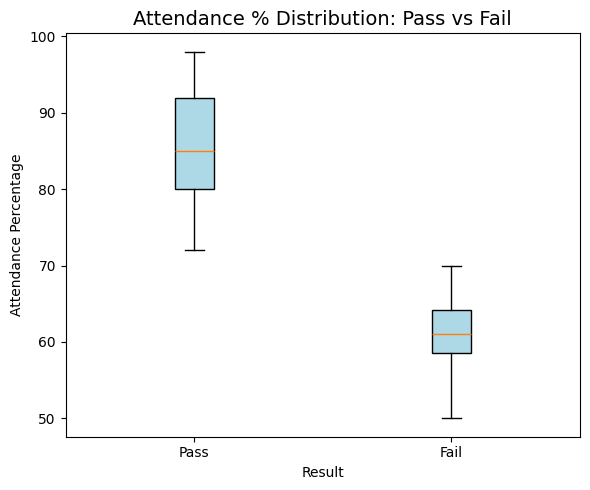

plot4_boxplot.png saved


In [6]:
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'],
           patch_artist=True, boxprops=dict(facecolor='lightblue'))

ax.set_title("Attendance % Distribution: Pass vs Fail", fontsize=14)
ax.set_xlabel("Result")
ax.set_ylabel("Attendance Percentage")

plt.tight_layout()
plt.savefig("plot4_boxplot.png")
plt.show()
print("plot4_boxplot.png saved")

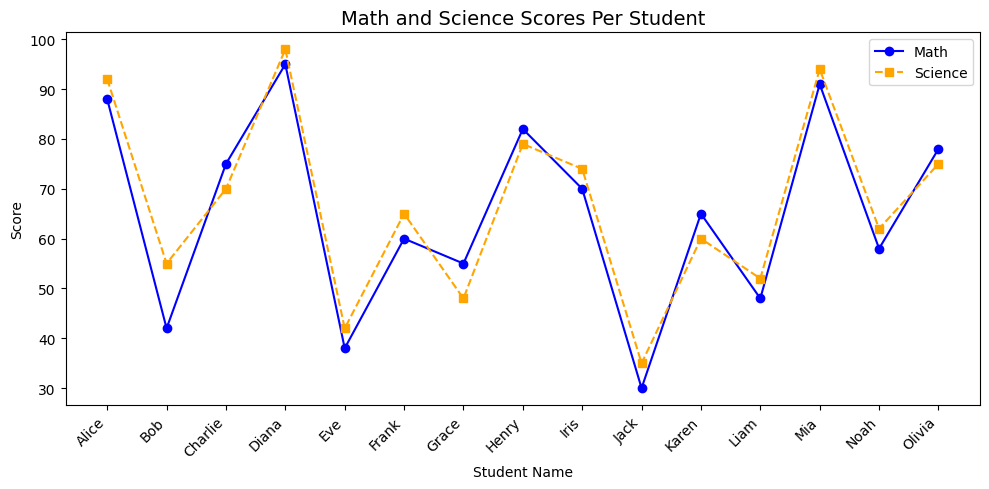

plot5_line.png saved


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df['name'], df['math'], marker='o', linestyle='-', label='Math', color='blue')
ax.plot(df['name'], df['science'], marker='s', linestyle='--', label='Science', color='orange')

ax.set_title("Math and Science Scores Per Student", fontsize=14)
ax.set_xlabel("Student Name")
ax.set_ylabel("Score")
ax.legend()

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()
print("plot5_line.png saved")

C:\Users\Isheeta\AppData\Local\Temp\ipykernel_8684\3314540532.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='math', ax=ax1, palette='Set2')
C:\Users\Isheeta\AppData\Local\Temp\ipykernel_8684\3314540532.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='science', ax=ax2, palette='Set1')


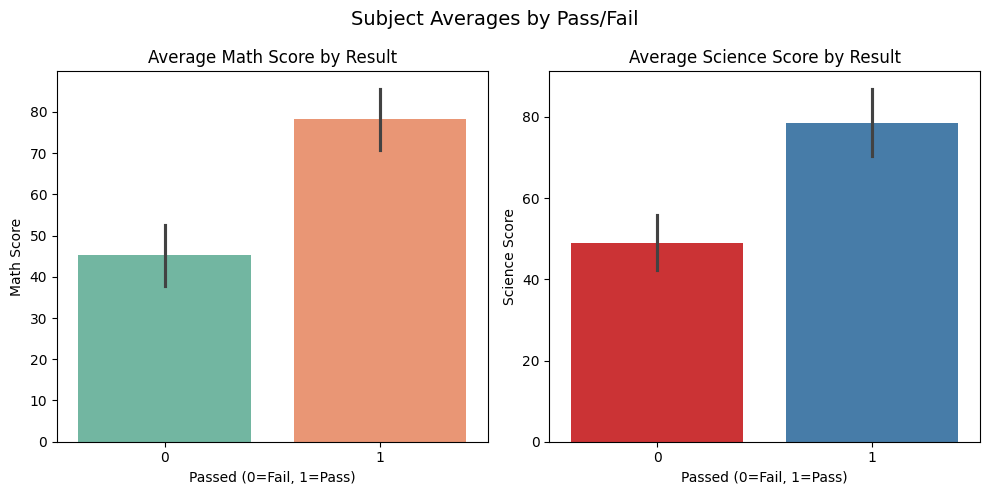

plot6_seaborn_bar.png saved


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(data=df, x='passed', y='math', ax=ax1, palette='Set2')
ax1.set_title("Average Math Score by Result")
ax1.set_xlabel("Passed (0=Fail, 1=Pass)")
ax1.set_ylabel("Math Score")

sns.barplot(data=df, x='passed', y='science', ax=ax2, palette='Set1')
ax2.set_title("Average Science Score by Result")
ax2.set_xlabel("Passed (0=Fail, 1=Pass)")
ax2.set_ylabel("Science Score")

plt.suptitle("Subject Averages by Pass/Fail", fontsize=14)
plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()
print("plot6_seaborn_bar.png saved")


# Reflection Comment
# Comparison: Using Seaborn was significantly easier for complex plots like the regression 
# analysis because it calculates the trend lines and confidence intervals automatically. 
# While Matplotlib was more straightforward for simple bar charts, it required a lot 
# more manual code to achieve the same level of visual polish that Seaborn provides by default.

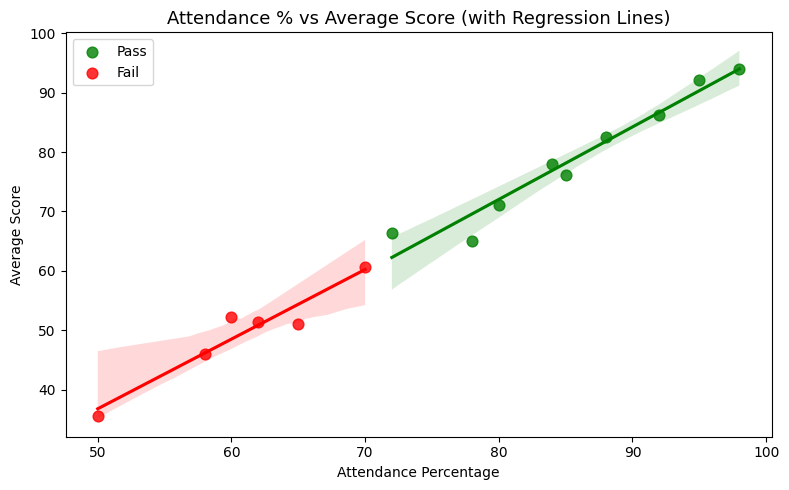

plot7_seaborn_scatter.png saved


In [9]:
# seaborn handles regression lines automatically vs matplotlib needing manual code
fig, ax = plt.subplots(figsize=(8, 5))

sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score',
            label='Pass', color='green', scatter_kws={'s': 60}, ax=ax)
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score',
            label='Fail', color='red', scatter_kws={'s': 60}, ax=ax)

ax.set_title("Attendance % vs Average Score (with Regression Lines)", fontsize=13)
ax.set_xlabel("Attendance Percentage")
ax.set_ylabel("Average Score")
ax.legend()

plt.tight_layout()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()
print("plot7_seaborn_scatter.png saved")

In [10]:
# task 4 - machine learning
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']

X = df[feature_cols]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)
print(f"Training Accuracy: {train_acc * 100:.2f}%")

y_pred   = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy    : {test_acc * 100:.2f}%")

test_names = df.loc[X_test.index, 'name']
print("\nPer-student predictions:")
for name, actual, predicted in zip(test_names, y_test, y_pred):
    result = "Correct" if actual == predicted else "Wrong"
    print(f"  {name:<10}  Actual: {'Pass' if actual==1 else 'Fail'}  Predicted: {'Pass' if predicted==1 else 'Fail'}  {result}")

Training Accuracy: 100.00%
Test Accuracy    : 100.00%

Per-student predictions:
  Jack        Actual: Fail  Predicted: Fail  Correct
  Liam        Actual: Fail  Predicted: Fail  Correct
  Alice       Actual: Pass  Predicted: Pass  Correct


Feature Coefficients (sorted by importance):
  english                   : 0.8125
  attendance_pct            : 0.5219
  study_hours_per_day       : 0.4844
  pe                        : 0.4750
  math                      : 0.4379
  science                   : 0.3230
  history                   : 0.2629


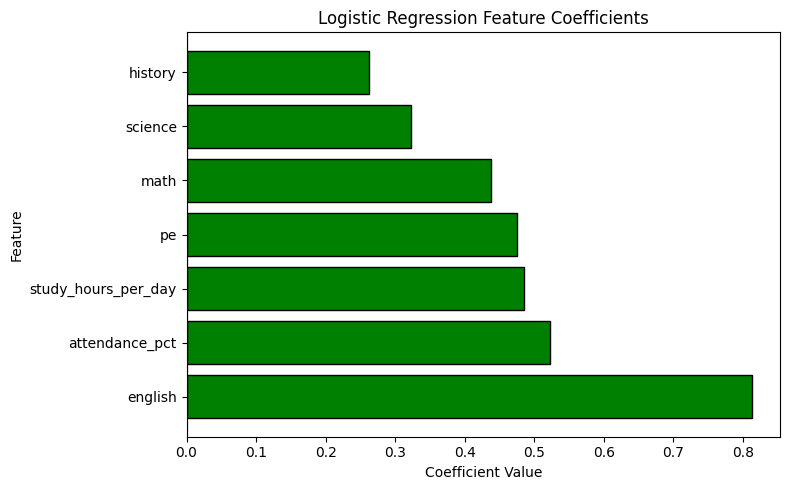

plot8_feature_importance.png saved


In [11]:
coefficients = model.coef_[0]
feature_importance = sorted(zip(feature_cols, coefficients), key=lambda x: abs(x[1]), reverse=True)

print("Feature Coefficients (sorted by importance):")
for feat, coef in feature_importance:
    print(f"  {feat:<25} : {coef:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
feat_names = [f[0] for f in feature_importance]
feat_coefs = [f[1] for f in feature_importance]
colors = ['green' if c > 0 else 'red' for c in feat_coefs]

ax.barh(feat_names, feat_coefs, color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Logistic Regression Feature Coefficients")
ax.set_xlabel("Coefficient Value")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig("plot8_feature_importance.png")
plt.show()
print("plot8_feature_importance.png saved")

In [12]:
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
new_scaled  = scaler.transform(new_student)

prediction  = model.predict(new_scaled)[0]
probability = model.predict_proba(new_scaled)[0]

print(f"New Student Prediction: {'Pass' if prediction == 1 else 'Fail'}")
print(f"Probability - Fail: {probability[0]:.2%}  |  Pass: {probability[1]:.2%}")

New Student Prediction: Pass
Probability - Fail: 9.20%  |  Pass: 90.80%


C:\Users\Isheeta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
